<a href="https://colab.research.google.com/github/s-aruneshwaran/Quantium-Data-Analytics-Virtual-Experience/blob/main/notebooks/Aruneshwaran_Sivakumar_Quantium_Data_Analytics_Virtual_Experience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Starting Data Cleaning & Feature Engineering ---

--> Searching for anomalies...
The culprit's Loyalty Card Number is: 226000
--> Outlier successfully removed from the dataset!

✅ Data cleaning complete. Saved as 'cleaned_qvi_data.csv'.

--- Analyzing Customer Segments ---


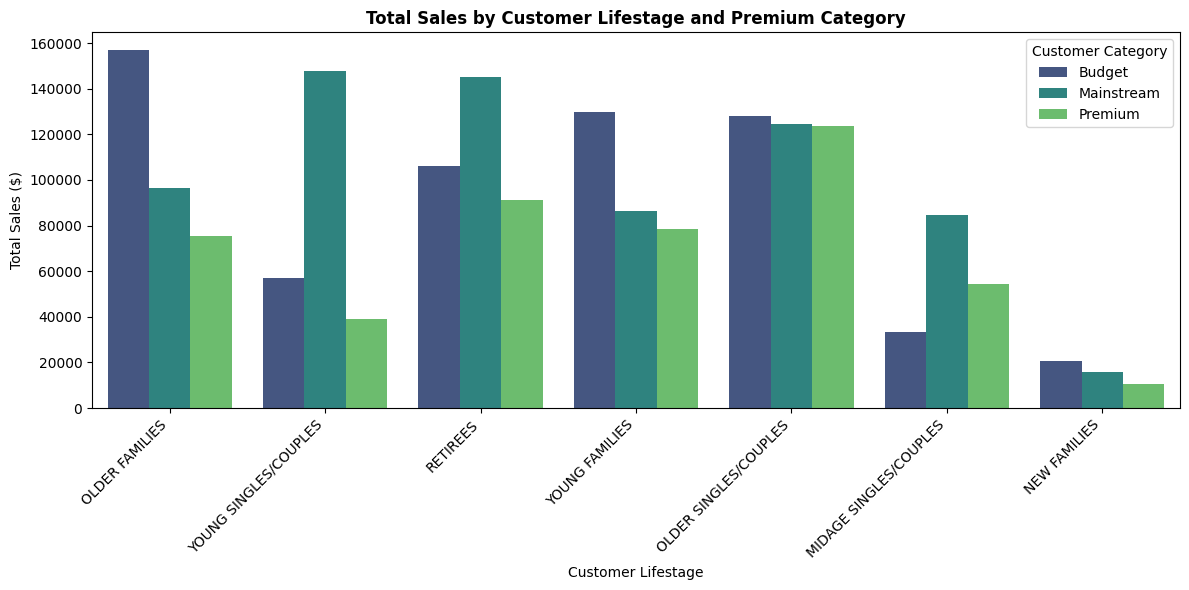


--- Deep Dive: Young Singles/Couples (Mainstream) ---

Top 5 Brands our Target Segment is unusually likely to buy (Affinity > 1 means higher preference):
BRAND
TYRRELLS    1.235751
TWISTIES    1.223096
DORITOS     1.210572
TOSTITOS    1.205700
KETTLE      1.193406
Name: proportion, dtype: float64

Top 5 Pack Sizes our Target Segment prefers (Affinity > 1 means higher preference):
PACK_SIZE
270.0    1.272269
380.0    1.256849
330.0    1.224477
134.0    1.181003
210.0    1.175546
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 1 & 2: DATA CLEANING & ENGINEERING
# ==========================================
print("--- Starting Data Cleaning & Feature Engineering ---\n")

# 1. Load the datasets
transaction_data = pd.read_excel("/content/QVI_transaction_data.xlsx")
customer_data = pd.read_csv("/content/QVI_purchase_behaviour.csv")

# 2. Convert Excel dates to readable calendar dates
transaction_data['DATE'] = pd.to_datetime(transaction_data['DATE'], origin='1899-12-30', unit='D')

# 3. Remove salsa products (we only want chips)
transaction_data = transaction_data[~transaction_data['PROD_NAME'].str.contains('salsa', case=False, na=False)]

# ---------------------------------------------------------
# 4. PROGRAMMATICALLY FIND AND REMOVE THE OUTLIER
# ---------------------------------------------------------
print("--> Searching for anomalies...")

# Find the absolute maximum quantity someone bought in one go
max_qty = transaction_data['PROD_QTY'].max()
print(f"Warning: Found an extreme transaction where someone bought {max_qty} bags of chips at once!")

# Locate the specific rows where this extreme purchase happened
outlier_transactions = transaction_data[transaction_data['PROD_QTY'] == max_qty]

# Extract the unique Loyalty Card Number of the person who did this
outlier_card_numbers = outlier_transactions['LYLTY_CARD_NBR'].unique()
print(f"The culprit's Loyalty Card Number is: {outlier_card_numbers[0]}")

# Ban this specific card number from our dataset (~ means 'keep everyone who is NOT in this list')
transaction_data = transaction_data[~transaction_data['LYLTY_CARD_NBR'].isin(outlier_card_numbers)]
print("--> Outlier successfully removed from the dataset!\n")
# ---------------------------------------------------------

# 5. Extract Pack Size (in grams) from the product name
transaction_data['PACK_SIZE'] = transaction_data['PROD_NAME'].str.extract(r'(\d+)')[0].astype(float)

# 6. Extract Brand Name (the first word of the product name) and make it uppercase
transaction_data['BRAND'] = transaction_data['PROD_NAME'].str.extract(r'^([a-zA-Z]+)')[0].str.upper()

# Clean up inconsistent brand names (e.g., 'REDONDO' and 'RRD' are the same brand)
brand_corrections = {
    'REDONDO': 'RRD', 'SNBTS': 'SUNBITES', 'INFZNS': 'INFUZIONS',
    'WW': 'WOOLWORTHS', 'SMITH': 'SMITHS', 'NCC': 'NATURAL',
    'DORITO': 'DORITOS', 'GRAIN': 'GRNWVES'
}
transaction_data['BRAND'] = transaction_data['BRAND'].replace(brand_corrections)

# 7. Merge the transaction data with the customer demographics
merged_data = pd.merge(transaction_data, customer_data, on='LYLTY_CARD_NBR', how='left')

# Save the final cleaned data
merged_data.to_csv('cleaned_qvi_data.csv', index=False)
print("✅ Data cleaning complete. Saved as 'cleaned_qvi_data.csv'.\n")


# ==========================================
# STEP 3: HIGH-LEVEL CUSTOMER ANALYSIS
# ==========================================
print("--- Analyzing Customer Segments ---")

# Calculate total sales per customer segment
sales_summary = merged_data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
sales_summary = sales_summary.sort_values(by='TOT_SALES', ascending=False)

# Visualize Total Sales by Segment
plt.figure(figsize=(12, 6))
sns.barplot(data=sales_summary, x='LIFESTAGE', y='TOT_SALES', hue='PREMIUM_CUSTOMER', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Total Sales by Customer Lifestage and Premium Category', fontweight='bold')
plt.xlabel('Customer Lifestage')
plt.ylabel('Total Sales ($)')
plt.legend(title='Customer Category')
plt.tight_layout()
plt.show()


# ==========================================
# STEP 4: DEEP DIVE INTO TOP SEGMENT
# ==========================================
print("\n--- Deep Dive: Young Singles/Couples (Mainstream) ---")

# Isolate our target segment vs the rest of the population
target_segment = merged_data[(merged_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') &
                             (merged_data['PREMIUM_CUSTOMER'] == 'Mainstream')]
other_segments = merged_data[~((merged_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') &
                               (merged_data['PREMIUM_CUSTOMER'] == 'Mainstream'))]

# 1. Brand Affinity (What brands do they prefer compared to everyone else?)
target_brand_pct = target_segment['BRAND'].value_counts(normalize=True)
other_brand_pct = other_segments['BRAND'].value_counts(normalize=True)

brand_affinity = (target_brand_pct / other_brand_pct).sort_values(ascending=False).head(5)
print("\nTop 5 Brands our Target Segment is unusually likely to buy (Affinity > 1 means higher preference):")
print(brand_affinity)

# 2. Pack Size Affinity (What sizes do they prefer?)
target_size_pct = target_segment['PACK_SIZE'].value_counts(normalize=True)
other_size_pct = other_segments['PACK_SIZE'].value_counts(normalize=True)

size_affinity = (target_size_pct / other_size_pct).sort_values(ascending=False).head(5)
print("\nTop 5 Pack Sizes our Target Segment prefers (Affinity > 1 means higher preference):")
print(size_affinity)

In [ ]:
import pandas as pd

print("--- Step 1: Calculating Monthly Store Metrics ---\n")

# 1. Load the dataset (Make sure QVI_data.csv is uploaded to Colab)
df = pd.read_csv("/content/QVI_data.csv")

# Convert the DATE column to a proper datetime format
df['DATE'] = pd.to_datetime(df['DATE'])

# 2. Create a "YEARMONTH" column (e.g., July 2018 becomes 201807)
# This makes it very easy to group our data by month
df['YEARMONTH'] = df['DATE'].dt.strftime('%Y%m').astype(int)

# 3. Calculate the monthly metrics for every single store
monthly_store_metrics = df.groupby(['STORE_NBR', 'YEARMONTH']).agg(
    TOT_SALES=('TOT_SALES', 'sum'),                  # Total revenue
    N_CUSTOMERS=('LYLTY_CARD_NBR', 'nunique'),       # Number of unique customers
    N_TXN=('TXN_ID', 'nunique')                      # Total number of transactions
).reset_index()

# 4. Calculate Average Transactions per Customer
monthly_store_metrics['TXN_PER_CUST'] = monthly_store_metrics['N_TXN'] / monthly_store_metrics['N_CUSTOMERS']

print("*** First 5 rows of our new Monthly Metrics table ***")
print(monthly_store_metrics.head())
print(f"\nTotal months of data recorded across all stores: {len(monthly_store_metrics)}")

--- Step 1: Calculating Monthly Store Metrics ---

*** First 5 rows of our new Monthly Metrics table ***
   STORE_NBR  YEARMONTH  TOT_SALES  N_CUSTOMERS  N_TXN  TXN_PER_CUST
0          1     201807      206.9           49     52      1.061224
1          1     201808      176.1           42     43      1.023810
2          1     201809      278.8           59     62      1.050847
3          1     201810      188.1           44     45      1.022727
4          1     201811      192.6           46     47      1.021739

Total months of data recorded across all stores: 3169


In [ ]:
import numpy as np

print("--- Step 2: Finding the Perfect Control Stores ---\n")

# 1. Filter for the Pre-Trial Period (July 2018 to Jan 2019)
pre_trial_metrics = monthly_store_metrics[monthly_store_metrics['YEARMONTH'] < 201902]

# Ensure we only use stores that have a full 7 months of pre-trial data
full_stores = pre_trial_metrics['STORE_NBR'].value_counts()
full_stores = full_stores[full_stores == 7].index

# 2. Create the Algorithm to find Control Stores
def find_best_control_store(trial_store_nbr):
    # Get the trial store's pre-trial data
    trial_data = pre_trial_metrics[pre_trial_metrics['STORE_NBR'] == trial_store_nbr].sort_values('YEARMONTH')
    trial_sales = trial_data['TOT_SALES'].values
    trial_cust = trial_data['N_CUSTOMERS'].values

    scores = []

    # Loop through every other store to find the best match
    for control_store_nbr in full_stores:
        if control_store_nbr == trial_store_nbr:
            continue

        control_data = pre_trial_metrics[pre_trial_metrics['STORE_NBR'] == control_store_nbr].sort_values('YEARMONTH')
        control_sales = control_data['TOT_SALES'].values
        control_cust = control_data['N_CUSTOMERS'].values

        # Calculate Pearson Correlation (1.0 is a perfect match in trends)
        sales_corr = np.corrcoef(trial_sales, control_sales)[0, 1]
        cust_corr = np.corrcoef(trial_cust, control_cust)[0, 1]

        # Calculate Magnitude Distance (Lower distance means the actual dollar/customer numbers are closer)
        sales_diff_mean = np.mean(np.abs(trial_sales - control_sales))

        # Combine the correlation scores to find the overall best fit
        final_score = (sales_corr + cust_corr) / 2

        scores.append({
            'Control_Store': control_store_nbr,
            'Correlation_Score': final_score,
            'Sales_Difference': sales_diff_mean
        })

    df_scores = pd.DataFrame(scores).dropna()
    # Sort to find the highest correlation with the lowest sales difference
    best_store = df_scores.sort_values(by=['Correlation_Score', 'Sales_Difference'], ascending=[False, True]).iloc[0]

    return int(best_store['Control_Store'])

# 3. Find the controls for our 3 Trial Stores
control_77 = find_best_control_store(77)
control_86 = find_best_control_store(86)
control_88 = find_best_control_store(88)

print(f"Trial Store 77 is paired with Control Store: {control_77}")
print(f"Trial Store 86 is paired with Control Store: {control_86}")
print(f"Trial Store 88 is paired with Control Store: {control_88}")

--- Step 2: Finding the Perfect Control Stores ---

Trial Store 77 is paired with Control Store: 233
Trial Store 86 is paired with Control Store: 155
Trial Store 88 is paired with Control Store: 178


--- Step 3: Assessing the Trial Impact (Visualizations) ---


ANALYZING TRIAL STORE 77 vs CONTROL STORE 233


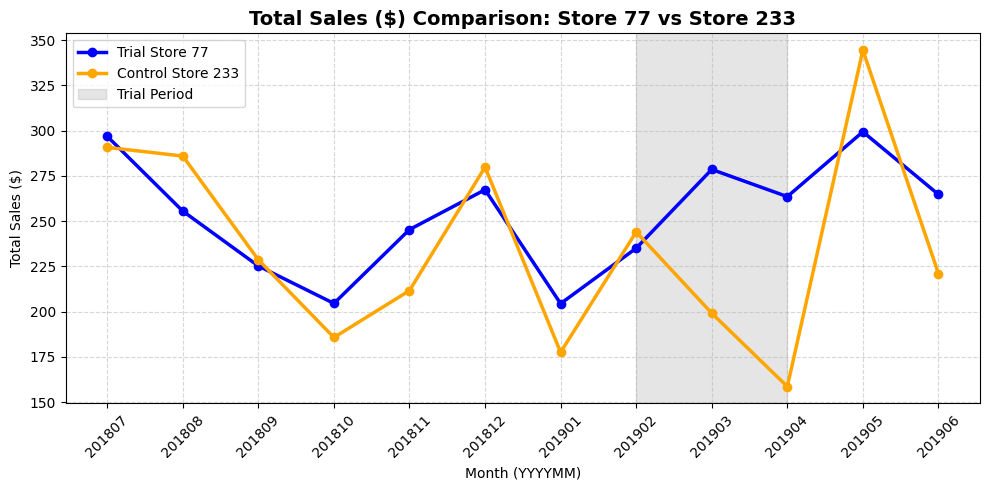

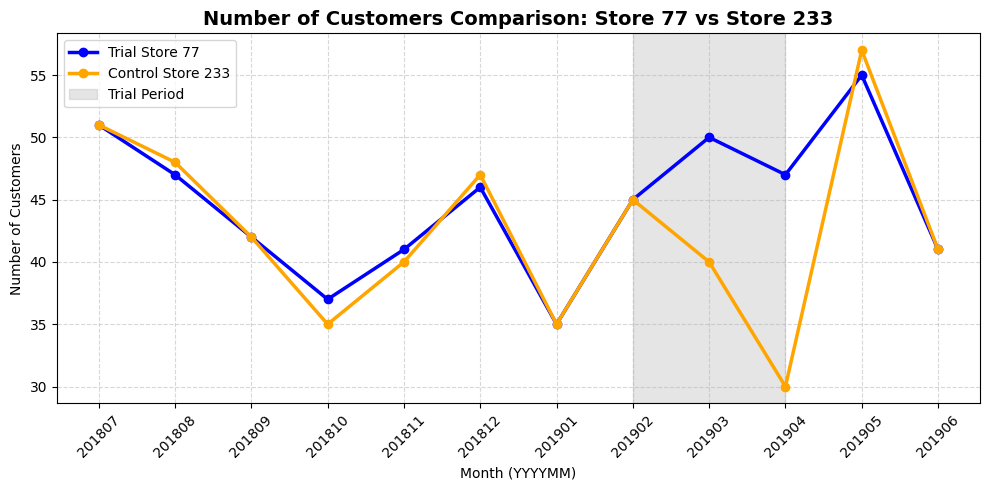


ANALYZING TRIAL STORE 86 vs CONTROL STORE 155


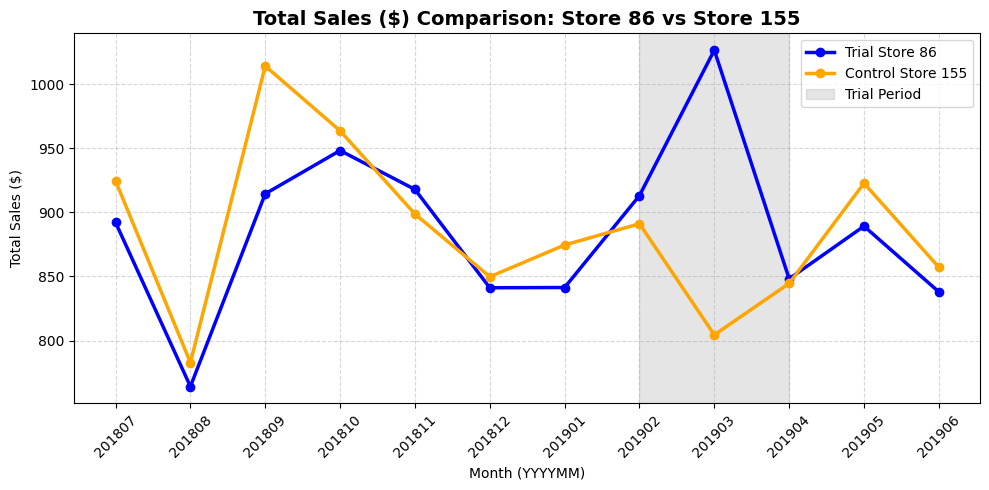

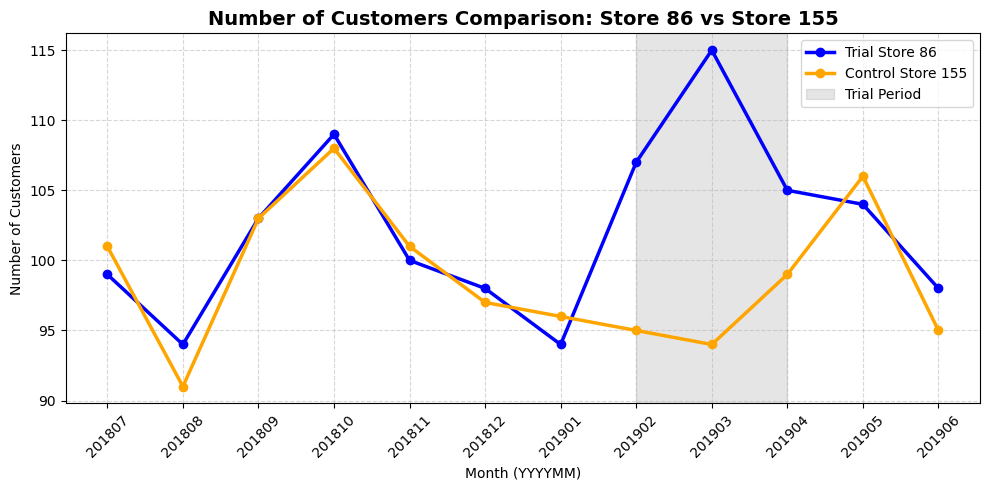


ANALYZING TRIAL STORE 88 vs CONTROL STORE 178


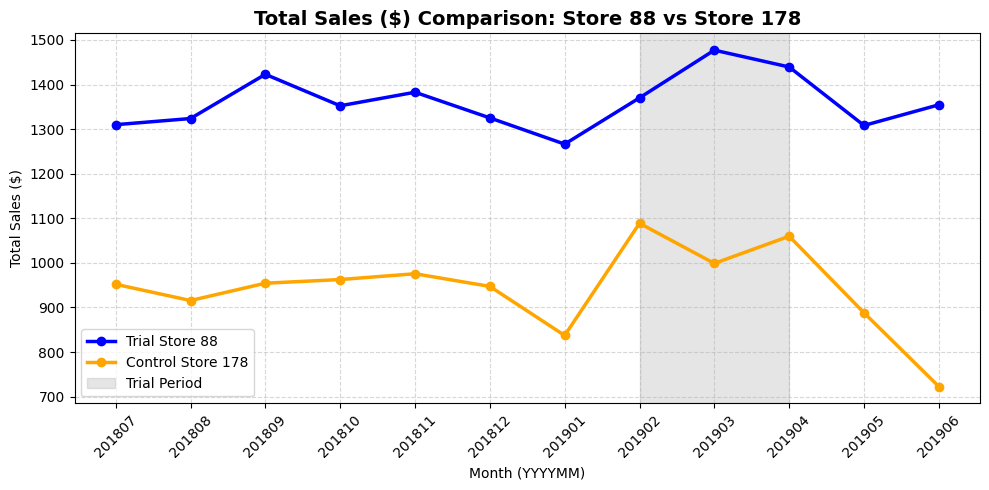

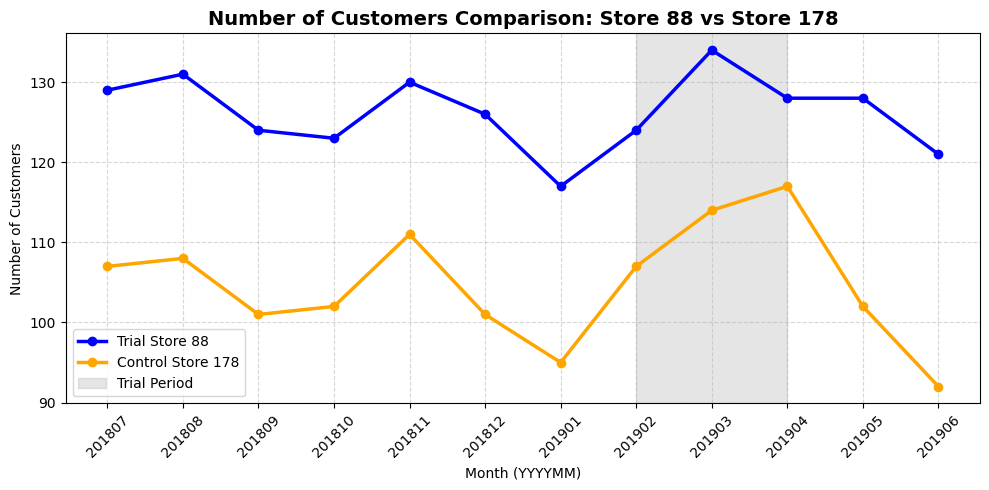

In [ ]:
import matplotlib.pyplot as plt

print("--- Step 3: Assessing the Trial Impact (Visualizations) ---\n")

# 1. Define the trial and control pairs we just found
pairs = {77: 233, 86: 155, 88: 178}

# 2. Make the YEARMONTH column look nicer for the x-axis of our charts
monthly_store_metrics['MONTH_STR'] = monthly_store_metrics['YEARMONTH'].astype(str)

# 3. Create a custom function to automatically plot the comparison charts
def plot_trial_vs_control(trial, control, metric, title_metric):
    plt.figure(figsize=(10, 5))

    # Get the data for the specific trial and control store
    trial_data = monthly_store_metrics[monthly_store_metrics['STORE_NBR'] == trial].sort_values('MONTH_STR')
    control_data = monthly_store_metrics[monthly_store_metrics['STORE_NBR'] == control].sort_values('MONTH_STR')

    # Plot the lines
    plt.plot(trial_data['MONTH_STR'], trial_data[metric], label=f'Trial Store {trial}', marker='o', color='blue', linewidth=2.5)
    plt.plot(control_data['MONTH_STR'], control_data[metric], label=f'Control Store {control}', marker='o', color='orange', linewidth=2.5)

    # Shade the background for the trial period (Feb 2019 to April 2019)
    plt.axvspan('201902', '201904', color='grey', alpha=0.2, label='Trial Period')

    # Add titles and labels
    plt.title(f'{title_metric} Comparison: Store {trial} vs Store {control}', fontsize=14, fontweight='bold')
    plt.xlabel('Month (YYYYMM)')
    plt.ylabel(title_metric)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# 4. Generate the charts for every pair!
for trial, control in pairs.items():
    print(f"\n=======================================================")
    print(f"ANALYZING TRIAL STORE {trial} vs CONTROL STORE {control}")
    print(f"=======================================================")
    plot_trial_vs_control(trial, control, 'TOT_SALES', 'Total Sales ($)')
    plot_trial_vs_control(trial, control, 'N_CUSTOMERS', 'Number of Customers')